In [ ]:
from torchvision import datasets, transforms
# transforms 전처리
from torch.utils.data import DataLoader
# 배치 필요
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# 디바이스 설정

# 전처리 도구
tfm = transforms.Compose([transforms.ToTensor()])
# 기존 데이터셋 가져와
train_ds = datasets.MNIST(root='/tmp/mnist', train=True, download=True, transform=tfm)  # (train 데이터)
test_ds  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=tfm) # test 데이터
# 일반적으로 배치 사이즈 같거나 2배 정도로
# 실무 코드에서 배치 다르게 하기도 -> 보통 train:test 8:2 정도로 데이터 양이 차이 나기 때문
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
# test 데이터: shuffle=False
# num_workers 코어 2개 지정
# pin_memory 메모리 공간 지정->GPU 있으면, 연산 속도 빨라져


100%|██████████| 9.91M/9.91M [00:00<00:00, 64.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.61MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.69MB/s]


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.f = nn.Sequential(
            nn.Flatten(), # 1차원 배열로
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)  # 10개로 출력
            # ReLU는 은닉층에서만 사용, 출력할 땐 사용X
        )
        # He 초기화 (ReLU에 아주 적합)
        for m in self.f:    # 각 모듈에 대해서
            if isinstance(m, nn.Linear):
                # 만약 m이 선형회귀(nn.Linear)라면
                nn.init.kaiming_normal_(m.weight)   # he 초기화
                nn.init.zeros_(m.bias)

    def forward(self,x):
        return self.f(x)


In [ ]:
# device 설정
model = MLP().to(device)
# Weight 자동 조절 -> 가중치 감쇠하는 최적화 함수
opt = optim.AdamW(model.parameters(), lr=3e-3)
# learning rate scheduler
sched = optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, steps_per_epoch=len(train_loader), epochs=5)
# criterion
crit = nn.CrossEntropyLoss()

In [ ]:
# gradient history 수집용 hook

grads = []  # 경사 변화 추적
def hook_fn(m, gi, go): # gradient in/gradient out
    if isinstance(m, nn.Linear):    # 모듈이 nn.Linear이면,
        if m.weight.grad is not None:
            grads.append(m.weight.grad.detach().abs().mean().item())  # 텐서 형태인 gradient를 떼어내서, 절대값 씌워서 평균치를 숫자로 바꿔줘
            # detach 변경되는 값을 떼어내는 것.

# hooks
hooks = [m.register_full_backward_hook(hook_fn)
for m in model.modules() if isinstance(m, nn.Linear)]

In [ ]:
def train_epoch():
    model.train()   # 선언
    # 초기화
    tot = 0
    correct = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        sched.step()    # scheduler도 같이 step 밟아야 한다.

        tot += y.size(0)
        # 현재 batch 샘플의 개수 누적
        # argmax 전체 예측값 중 가장 큰 값을 가지는 인덱스 반환
        correct += (out.argmax(1) == y).sum().item()
        # 예측값이 정답과 같은 것의 개수를 더해서, 파이썬 숫자로 correct에 더하기
    return loss.item(), correct/tot

In [ ]:
def eval_epoch():
    model.eval()
    tot = 0
    correct = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            tot += y.size(0)
            correct += (out.argmax(1) ==y).sum().item()
            # (out.argmax(1)==y) >> True(1) / False(0)
    return correct/tot

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_12869/633885671.py:11: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


ep1 loss=0.229 test_acc=0.949
ep2 loss=0.111 test_acc=0.973
ep3 loss=0.035 test_acc=0.981
ep4 loss=0.039 test_acc=0.983
ep5 loss=0.011 test_acc=0.984


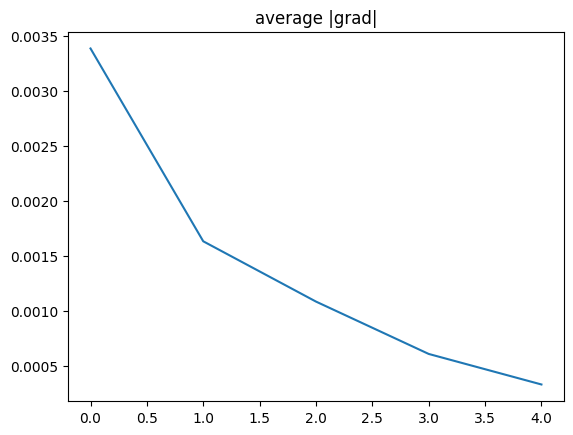

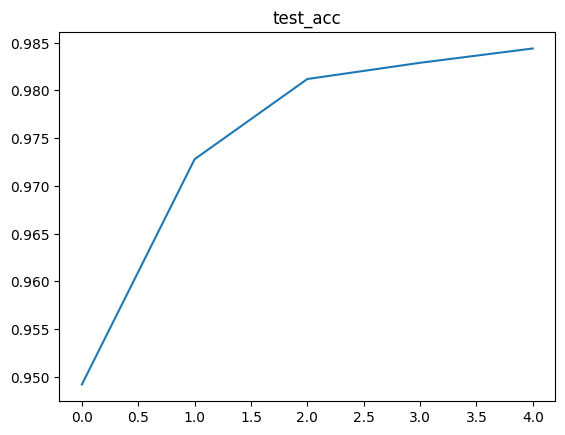

In [ ]:
hist_grad = []
hist_acc = []

for ep in range(5):
    # 재귀적 용법 -> 함수 만들어 사용 ; 훨씬 효율적
    loss, tr_acc = train_epoch()
    acc = eval_epoch()
    hist_grad.append(sum(grads[-len(train_loader):])/max(1, len(train_loader)))
    # grads[-len(train_loader):] >> 마지막 에폭의 기울기
    # max(1, len(train_loader)) >> 분모 0 되면 zero division error 방지
    hist_acc.append(acc)
    print(f"ep{ep+1} loss={loss:.3f} test_acc={acc:.3f}")

plt.figure()
plt.plot(hist_grad)
plt.title("average |grad|")
plt.show()

plt.figure()
plt.plot(hist_acc)
plt.title("test_acc")
plt.show()

for h in hooks:
    h.remove()

### 보충학습

In [ ]:
# argmax / item

scores = [10, 25, 7, 35]
scores = torch.tensor(scores)
print(scores)

print(scores.argmax().item())
# 가장 큰 값을 가지고 있는 index 출력
# item() 값만 가져오기(파이썬 내 숫자로)

tensor([10, 25,  7, 35])
3


In [ ]:
out = [
 [0.1, 2.3, 0.5, 1.1],
 [3.2, 0.4, 1.8, 0.9],
 [0.2, 1.1, 4.0, 0.3]
]

out = torch.tensor(out)
print(out.shape)

torch.Size([3, 4])


In [ ]:
out.argmax()

tensor(10)

In [ ]:
out.argmax(1)   # axis=1
# argmax() 가장 큰 값을 가지고 있는 인덱스(위치)
# axis = 1

# axis = 0(default)
# 각 행에서 가장 큰 인덱스 반환

tensor([1, 0, 2])

In [ ]:
# max와 argmax 차이
out.max()   # 가장 큰 값(value)

tensor(4.)

In [ ]:
scores = [10, 25, 7, 35]
scores[-3:]

[25, 7, 35]

In [ ]:
sum(scores[-3:])

67

In [ ]:
sum(scores[-3:]) / 3

22.333333333333332

In [ ]:
len(scores)

4

In [ ]:
sum(scores) / len(scores)   # 평균

19.25

In [ ]:
sum(scores[-len(scores):])/max(1,len(scores))

19.25